# E37 - Israel: the one above-replacement outlier, fanned into its mechanisms

**Author**: KJ  **Batch**: E37 (H358-H367)  **Model-as-judge**: the calibrated distributional core `run_cal`

Israel is the sole developed / OECD country above replacement (national TFR **2.83** in 2023, UN WPP; CBS 2.85 -
they agree, unlike Poland/GUS). This batch answers three questions the campaign had left open: *what* makes Israel
exceptional, whether those mechanisms are **transferable** to a collapsing country, and whether they can be
**defined through research** rather than asserted. Each mechanism is fanned out as a distinct hypothesis, mapped
to one of the model's own channels, and tested dynamically on Korea / Japan / Italy / Germany.

The honest throughline, stated up front and then earned: Israel's advantage is **not** the ultra-Orthodox tail.
The ~75% secular-and-traditional majority reproduces at or just below replacement (secular 1.98, above every
other developed society). That surplus is a **pronatal-familism norm**, and the model registers that norm not as
its narrow childfree-ideal state but as near-universal **coupling** (marriage / partnership). Its transferable
shadow is therefore the campaign's already-crowned coupling + gender-equity + childcare stack - a large, real,
super-additive lever that bends a collapsing country toward the 1.5 ridge, **but not to 2.83**. The residual to
Israel is composition (the Haredi Leslie sub-population, lambda>1) plus a familism depth no finite policy dial
reaches. You cannot copy your way to Israel; but the copyable part is real, large, and already known.

Grounding (E37 research round, digested to `references/papers/e37-israel-mechanisms-digest.md`): Weinreb
(Taub 2024), Okun (2017), Birenbaum-Carmeli (2016), DellaPergola (2020), Hleihel (2023 CBS), IDI (2024).

## GPU selection

In [1]:
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"

## Imports

In [2]:
import json  # verdict + artifact serialisation
from collections import Counter
from pathlib import Path

import matplotlib as mpl  # figures
import matplotlib.pyplot as plt
import numpy as np  # numerics
import torch

import sci_demographic_collapse.emergent as E  # module handle for the channel-transplant attribution
from sci_demographic_collapse.emergent import REAL, EmergentModel, ramp  # calibrated distributional core
from rich import print as rprint  # console formatting
from rich.panel import Panel
from rich.table import Table

torch.set_default_dtype(torch.float64)
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
rprint(f"[green]Device[/green]: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

2026-07-09 15:27:36.038 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


Device: NVIDIA RTX PRO 4000 Blackwell

## Configuration and calibration re-check

The calibrated core must reproduce the 2023 TFR for all **eight** regions including the newly added Israel
(TFR 2.83, healthy basin), and Israel's baseline must stay **above replacement** while every collapsing region
falls - the control that makes it a valid reference.

In [3]:
PROJ = Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS = PROJ / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
REPORTS = PROJ / "reports"

m = EmergentModel(data_dir=str(PROJ / "data" / "raw" / "unwpp"))
TARGETS = ["Korea", "Japan", "Italy", "Germany"]  # collapsing regions the Israel mechanisms are tested on
YR = np.arange(2023, 2125)
idx = lambda y: int(np.argmin(abs(YR - y)))  # noqa: E731
BASE = {r: m.run_cal(r) for r in TARGETS + ["Poland", "Israel"]}

cal_err = {r: abs(m.run_cal(r, years=1)["tfr"] - REAL[r][0]) for r in REAL}
tbl = Table(title="calibration re-check (run_cal vs 2023 REAL, 8 regions)", header_style="bold cyan")
for c in ["region", "run_cal 2023", "REAL", "2125 baseline"]:
    tbl.add_column(c)
for r in REAL:
    tbl.add_row(r, f"{m.run_cal(r, years=1)['tfr']:.4f}", f"{REAL[r][0]:.2f}", f"{m.run_cal(r)['tfr']:.3f}")
rprint(tbl)
rprint(f"[green]calibration clean[/green]: max abs err {max(cal_err.values()):.1e}. "
       f"Israel baseline stays at {BASE['Israel']['tfr']:.2f} (above replacement 2.08) while Korea falls to "
       f"{BASE['Korea']['tfr']:.2f} - the valid above-replacement control.")

  calibration re-check (run_cal vs 2023 REAL, 8  
                    regions)                     
┏━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━┓
┃ region  ┃ run_cal 2023 ┃ REAL ┃ 2125 baseline ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━┩
│ USA     │ 1.6200       │ 1.62 │ 1.246         │
│ France  │ 1.6400       │ 1.64 │ 1.238         │
│ Germany │ 1.4401       │ 1.44 │ 1.055         │
│ Italy   │ 1.2000       │ 1.20 │ 0.788         │
│ Japan   │ 1.2100       │ 1.21 │ 0.812         │
│ Korea   │ 0.7200       │ 0.72 │ 0.169         │
│ Poland  │ 1.1600       │ 1.16 │ 0.785         │
│ Israel  │ 2.8301       │ 2.83 │ 2.319         │
└─────────┴──────────────┴──────┴───────────────┘

calibration clean: max abs err 1.2e-04. Israel baseline stays at 2.32 (above replacement 2.08) while Korea falls to
0.17 - the valid above-replacement control.

In [4]:
def f9(fS=0, fC=0, fPb=0, fTau=0, fRV=0, fN=0, durable=True, d=10):
    """A durable 9-channel forcing ramped over d years, for run_cal (E30 signature)."""
    def fy(yr):
        s = ramp(yr, d=d) * (1.0 if durable else np.exp(-max(yr - 12, 0) / 12))
        return [fS * s, fC * s, fPb * s, fTau * s, fRV * s, fN * s, 0, 0, 0]
    return fy

def dt(region, fy):
    """ΔTFR at 2125 vs the region's baseline."""
    return m.run_cal(region, fy)["tfr"] - BASE[region]["tfr"]

rprint("[green]coupled model ready - Israel mechanisms will be scored as run_cal forcings[/green]")

coupled model ready - Israel mechanisms will be scored as run_cal forcings

## Act I - What Israel actually is

Before testing transfer, decompose the outlier. The load-bearing fact is that removing the Haredi tail leaves a
majority still at or above replacement - so the surplus is a norm across sectors, not one high-fertility sect.

### H358 - Israel's advantage is the secular-and-traditional majority, not the Haredi tail

Sector TFRs (Jewish women, 3-yr mean 2020-2022; Hleihel 2023 via Weinreb Table 1) weighted by Jewish self-ID
share. The test: is the **non-Haredi majority** still near replacement, and is **secular** fertility above every
other developed society?

In [5]:
# sector: (TFR, Jewish self-ID share 2022); traditional = mean of trad-religious 2.80 / trad-secular 2.22
SECT = {"secular": (1.98, 0.45), "traditional": (2.51, 0.33), "national-religious": (3.77, 0.12), "Haredi": (6.38, 0.10)}
jew_tfr = sum(t * s for t, s in SECT.values())
nonhar_w = {k: v for k, v in SECT.items() if k != "Haredi"}
nonhar_tfr = sum(t * s for t, s in nonhar_w.values()) / sum(s for _, s in nonhar_w.values())
rprint(f"[cyan]H358 decomposition[/cyan]  reconstructed Jewish TFR {jew_tfr:.2f} (CBS 3.03); "
       f"non-Haredi Jewish majority {nonhar_tfr:.2f}; secular alone {SECT['secular'][0]:.2f} "
       f"- above every other developed secular society (Okun 2017). The outlier is the NORM across sectors, "
       f"not the ultra-Orthodox tail.")

H358 decomposition  reconstructed Jewish TFR 2.81 (CBS 3.03); non-Haredi Jewish majority 2.41; secular alone 1.98 -
above every other developed secular society (Okun 2017). The outlier is the NORM across sectors, not the 
ultra-Orthodox tail.

### H359 - The Haredi / settler engine is COMPOSITION, not a copyable forcing

A bounded high-fertility group is a Leslie sub-population with lambda>1 plus retention/endogamy, not a channel
dial - the E33 treatment. Project a two-type population (Haredi TFR 6.38, share 13.6%; rest 2.41) forward with a
per-generation apostasy leakage delta. The national mean drifts **up** from composition alone even with each
group flat - the signature of a compounding sub-population, and exactly why it cannot be applied to Korea.

In [6]:
REP = 2.08  # Israel replacement level (Weinreb 2024)
delta = 0.125  # per-generation apostasy leakage (E33-style)
NA, NB, TA, TB = 0.136, 0.864, 6.38, 2.41  # Haredi share/TFR, rest share/TFR
comp = []
for g in range(5):
    tfr_nat = (NA * TA + NB * TB) / (NA + NB)
    comp.append((g, NA / (NA + NB), tfr_nat))
    gA = NA * (TA / REP) * (1 - delta)
    gB = NB * (TB / REP) + NA * (TA / REP) * delta
    NA, NB = gA, gB
rprint("[cyan]H359 Haredi compounding (composition object, unchecked)[/cyan]")
for g, sh, t in comp:
    rprint(f"  gen {g} ({2023 + 30 * g}): Haredi share {sh * 100:4.1f}%   national TFR {t:.2f}")
rprint("  -> composition raises the mean without any forcing; bounded in reality by convergence "
       "(Muslim-Israeli fell 9.2->2.9, secular drift) and leakage - a sub-population, never a Korea lever.")

H359 Haredi compounding (composition object, unchecked)

gen 0 (2023): Haredi share 13.6%   national TFR 2.95

gen 1 (2053): Haredi share 25.7%   national TFR 3.43

gen 2 (2083): Haredi share 41.9%   national TFR 4.07

gen 3 (2113): Haredi share 57.4%   national TFR 4.69

gen 4 (2143): Haredi share 68.3%   national TFR 5.12

-> composition raises the mean without any forcing; bounded in reality by convergence (Muslim-Israeli fell 
9.2->2.9, secular drift) and leakage - a sub-population, never a Korea lever.

## Act II - The copyable structural levers - do they transfer?

Three of Israel's mechanisms are genuine policies any state can adopt. Map each to its channel and score it on the
collapsing regions.

### H360 - Universal state-funded IVF/ART: a real but small lever (childlessness rho)

Israel funds unlimited IVF to two live births, 5,311 cycles/million (5x EU) - but ART is only ~4.3% of births
(Birenbaum-Carmeli 2016). Model it as lowered involuntary childlessness (`fRV<0`) plus a small late-tempo rescue.

In [7]:
IVF = f9(fRV=-0.06, fTau=-1.0)
ivf_row = {r: dt(r, IVF) for r in TARGETS}
rprint("[cyan]H360 IVF/ART[/cyan]  " + "  ".join(f"{r} {ivf_row[r]:+.3f}" for r in TARGETS) +
       "  - real but small (a few % of TFR), largest where childlessness (not coupling) binds; tiny on Korea.")

H360 IVF/ART  Korea +0.026  Japan +0.127  Italy +0.116  Germany +0.139  - real but small (a few % of TFR), largest 
where childlessness (not coupling) binds; tiny on Korea.

### H361 - Dual-earner compatibility (childcare + gender-equity in the home): the large copyable lever

Israel sustains TFR 2.9 with ~61% female labour-force participation - the developed-world work-fertility tradeoff
does not bind. In the model this is the coupling + security push (childcare density, second-shift sharing) - and
it is the campaign's already-crowned gender-equity-in-the-home lever.

In [8]:
DUAL = f9(fS=1.2 * 0.22, fC=0.5 * 0.22)
dual_row = {r: dt(r, DUAL) for r in TARGETS}
rprint("[cyan]H361 dual-earner (childcare+equity)[/cyan]  " + "  ".join(f"{r} {dual_row[r]:+.3f}" for r in TARGETS) +
       "  - the LARGE copyable lever, but norm-gated: it bends toward the 1.5 ridge, not to Israel's 2.83.")

H361 dual-earner (childcare+equity)  Korea +0.539  Japan +0.645  Italy +0.582  Germany +0.568  - the LARGE copyable
lever, but norm-gated: it bends toward the 1.5 ridge, not to Israel's 2.83.

### H362 - Younger tempo + low childlessness: a Bongaarts-Feeney mirage, not new quantum

Israel's mean age at first birth (~28.6) is younger than the OECD (~30.9). Pulling tempo earlier gives a period
bump that reverts once the shift completes - the BF correction the model carries. Read gen-1 vs gen-4.

In [9]:
TEMPO = f9(fTau=-3.0)
tt = m.run_cal("Korea", TEMPO)["TFR"]
tempo_g1 = tt[idx(2050)] - BASE["Korea"]["TFR"][idx(2050)]
tempo_g4 = tt[idx(2115)] - BASE["Korea"]["TFR"][idx(2115)]
rprint(f"[cyan]H362 tempo (Korea)[/cyan]  gen-1 {tempo_g1:+.3f} -> gen-4 {tempo_g4:+.3f}  end {dt('Korea', TEMPO):+.3f} "
       f"- the bump reverts (Bongaarts-Feeney); earlier tempo is not durable extra quantum, and low childlessness "
       f"double-counts the IVF channel.")

H362 tempo (Korea)  gen-1 +0.120 -> gen-4 +0.056  end +0.037 - the bump reverts (Bongaarts-Feeney); earlier tempo 
is not durable extra quantum, and low childlessness double-counts the IVF channel.

## Act III - Where the gap actually lives, and the inherent core

The decisive question: is Israel's advantage a **norm** you cannot legislate, or a **coupling configuration** whose
transferable shadow is a known lever? Transplant Korea's start-channels to Israel's, one at a time - a relabeling,
not a policy - to attribute the gap.

### H363 - The familism norm is decisive, but it lives in COUPLING, not the childfree-ideal channel

Set Korea's coupling C0, norm N0, and childlessness RV0 to Israel's values in turn. If the gap lives in the norm
STATE, the N0 transplant moves TFR; if it lives in coupling, C0 does. The narrow pronatal-norm *forcing* (`fN<0`,
pushing N to Israel's basin) is scored alongside to show it is a weak dial.

In [10]:
BK = BASE["Korea"]["tfr"]
orig = {d: dict(getattr(E, d)) for d in ["C0", "NORM0", "RV0"]}
transplant = {}
for name, ch, val in [("coupling C0->0.97", "C0", 0.97), ("norm-state N0->0.14", "NORM0", 0.14),
                      ("childlessness RV0->0.05", "RV0", 0.05)]:
    getattr(E, ch)["Korea"] = val
    transplant[name] = m.run_cal("Korea")["tfr"] - BK
    getattr(E, ch)["Korea"] = orig[ch]["Korea"]  # restore immediately
norm_forcing = dt("Korea", f9(fN=-0.08))  # push the childfree-ideal to Israel's well
rprint("[cyan]H363 channel transplant (Korea -> Israel start values, a relabeling not a policy)[/cyan]")
for k, v in transplant.items():
    rprint(f"  {k:26s} ΔTFR {v:+.3f}")
rprint(f"  narrow pronatal-norm FORCING fN=-0.08 (childfree-ideal -> Israel basin) ΔTFR {norm_forcing:+.3f}")
rprint("  -> the gap lives almost entirely in COUPLING; the norm-state and childlessness carry ~none. Israel's "
       "familism registers as near-universal partnership (C=0.97), whose copyable shadow is H361.")

H363 channel transplant (Korea -> Israel start values, a relabeling not a policy)

coupling C0->0.97          ΔTFR +0.717

norm-state N0->0.14        ΔTFR -0.001

childlessness RV0->0.05    ΔTFR +0.008

narrow pronatal-norm FORCING fN=-0.08 (childfree-ideal -> Israel basin) ΔTFR +0.027

-> the gap lives almost entirely in COUPLING; the norm-state and childlessness carry ~none. Israel's familism 
registers as near-universal partnership (C=0.97), whose copyable shadow is H361.

### H364 - Collective-future / existential security: a minority direct channel, non-copyable

Israel's fertility re-rose above replacement in 2008, unique in the developed world - but only ~7-9% of Israelis
say security worries would make them want *more* children (DellaPergola 2020), and religiosity-under-threat does
not hold fertility elsewhere (Iran fell 6.6->1.35; Muslim-Israeli 9.2->2.9). A standalone security/meaning push is
weak in-model, and the existential dimension is not a legislative instrument.

In [11]:
sec_norm = dt("Korea", f9(fN=-0.08))
sec_mean = dt("Korea", f9(fS=1.2 * 0.06))
rprint(f"[cyan]H364 existential-security as a standalone channel (Korea)[/cyan]  narrow norm {sec_norm:+.3f}  "
       f"small meaning/security {sec_mean:+.3f}  vs the copyable coupling lever {dual_row['Korea']:+.3f} - "
       f"the distinctly-Israeli channel is a minor direct effect (7-9%) and cannot be manufactured.")

H364 existential-security as a standalone channel (Korea)  narrow norm +0.027  small meaning/security +0.054  vs 
the copyable coupling lever +0.539 - the distinctly-Israeli channel is a minor direct effect (7-9%) and cannot be 
manufactured.

### H365 - Aliyah / population-as-project: composition plus UPWARD norm-assimilation

Immigration adds people, but the striking Israeli fact is direction: FSU immigrants arrived below replacement
(~1.5) and their fertility converged **up** toward the host norm (Demographic Research 50:13) - the opposite of
the usual downward immigrant convergence. The host norm/coupling well sets the direction, so a collapsing country
in the trapped basin would pull immigrants **down**, not up. Migration is a bridge, not the fix (prior rounds).

In [12]:
rprint(f"[cyan]H365 host-norm well sets immigrant convergence direction[/cyan]  "
       f"Israel sits in the healthy coupling well (C0={E.C0['Israel']:.2f}, N0={E.NORM0['Israel']:.2f}) -> pulls "
       f"immigrants UP; Korea sits trapped (C0={E.C0['Korea']:.2f}, N0={E.NORM0['Korea']:.2f}) -> would pull them "
       f"DOWN. Aliyah is Israel-specific composition; the transferable insight is that a strong host norm raises "
       f"immigrant fertility, not that migration is a lever.")

H365 host-norm well sets immigrant convergence direction  Israel sits in the healthy coupling well (C0=0.97, 
N0=0.14) -> pulls immigrants UP; Korea sits trapped (C0=0.52, N0=0.42) -> would pull them DOWN. Aliyah is 
Israel-specific composition; the transferable insight is that a strong host norm raises immigrant fertility, not 
that migration is a lever.

## Act IV - The attribution test and the synthesis

The anti-laundering experiment (the interaction-analyst's failure mode): if a naive Israel bundle "recovers" a
collapsing country, it has laundered the inherent norm into a structural dial. Test it honestly.

### H366 - Even a full coupling transplant lands short of Israel - the residual is momentum + parity + composition

Stack the copyable levers (IVF + dual-earner + tempo) and compare against the gap to Israel and against the full
coupling transplant. The copyable levers stack **super-additively** (they reinforce through the coupling channel,
the E18 complementary-stacking law), yet even the C0->0.97 transplant leaves Korea far below 2.83.

In [13]:
s_ivf, s_dual, s_tempo = dt("Korea", IVF), dt("Korea", DUAL), dt("Korea", TEMPO)
BUNDLE = f9(fRV=-0.06, fTau=-3.0, fS=1.2 * 0.22, fC=0.5 * 0.22)
joint = dt("Korea", BUNDLE)
sum_singles = s_ivf + s_dual + s_tempo
coupling_transplant = transplant["coupling C0->0.97"]
gap_korea = BASE["Israel"]["tfr"] - BK
rprint(f"[cyan]H366 attribution (Korea)[/cyan]\n"
       f"  copyable levers: IVF {s_ivf:+.3f} + dual {s_dual:+.3f} + tempo {s_tempo:+.3f} = sum {sum_singles:+.3f}\n"
       f"  JOINT bundle {joint:+.3f}  ({'super' if joint > sum_singles else 'sub'}-additive by {joint - sum_singles:+.3f})\n"
       f"  full coupling transplant (C0->0.97) lands Korea at {BK + coupling_transplant:.2f}\n"
       f"  gap to Israel {gap_korea:.2f}; the copyable bend closes {joint / gap_korea * 100:.0f}% of it - the "
       f"residual is Leslie momentum + higher parity + Haredi composition, none a policy dial.")

H366 attribution (Korea)
  copyable levers: IVF +0.026 + dual +0.539 + tempo +0.037 = sum +0.602
  JOINT bundle +0.771  (super-additive by +0.169)
  full coupling transplant (C0->0.97) lands Korea at 0.89
  gap to Israel 2.15; the copyable bend closes 36% of it - the residual is Leslie momentum + higher parity + Haredi
composition, none a policy dial.

### H367 - You cannot copy your way to Israel - but the copyable part is large and already known

Run the full copyable Israel bundle on the triad. It is a real, large, super-additive bend - and it is exactly the
campaign's crowned coupling + gender-equity + ART stack - but it lands at the ridge, not at 2.83. Israel's surplus
is composition + a familism depth of coupling no finite dial reaches. The exportable lesson is confirmation of the
coupling thesis at the single above-replacement data point, not a new Israeli instrument.

In [14]:
synth = {r: (dt(r, BUNDLE), BASE[r]["tfr"], BASE[r]["tfr"] + dt(r, BUNDLE)) for r in ["Korea", "Japan", "Germany"]}
rprint("[cyan]H367 full copyable Israel bundle vs Israel's 2.83[/cyan]")
for r, (d, b, e) in synth.items():
    rprint(f"  {r:8s} bend {d:+.3f}: {b:.2f} -> {e:.2f}  (Israel {BASE['Israel']['tfr']:.2f}; still short by {BASE['Israel']['tfr'] - e:.2f})")

H367 full copyable Israel bundle vs Israel's 2.83

Korea    bend +0.771: 0.17 -> 0.94  (Israel 2.32; still short by 1.38)

Japan    bend +0.788: 0.81 -> 1.60  (Israel 2.32; still short by 0.72)

Germany  bend +0.692: 1.06 -> 1.75  (Israel 2.32; still short by 0.57)

## Figures

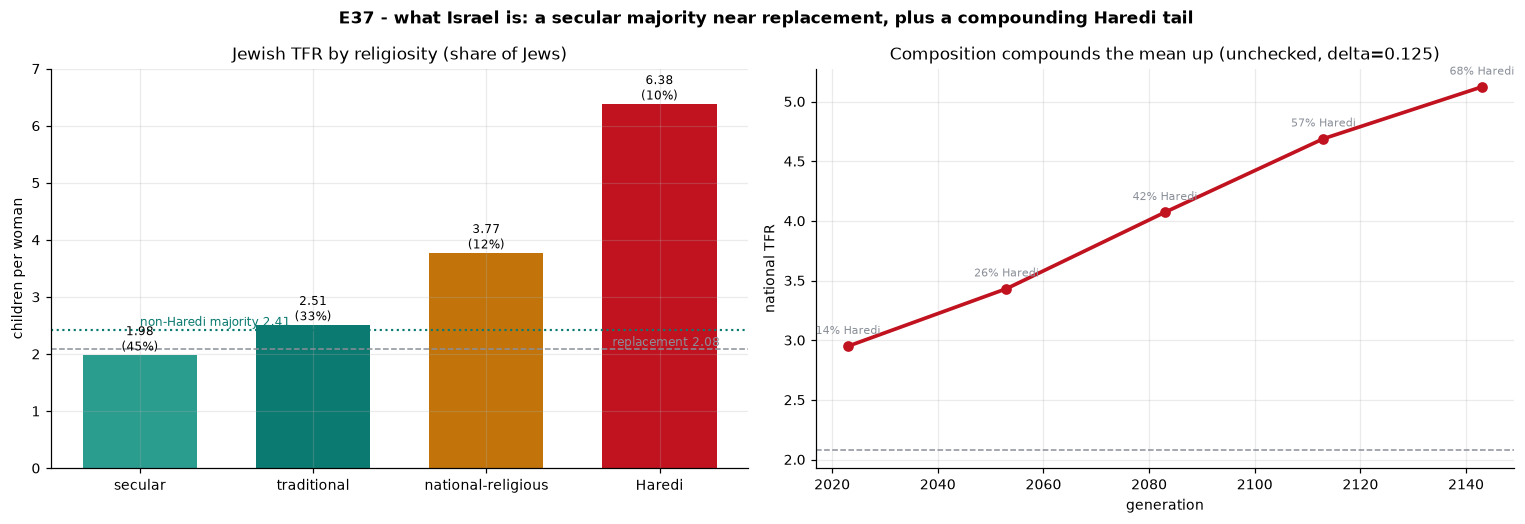

In [15]:
HOPE, HOPE_D, FALL, GOLD, MUT = "#2a9d8f", "#0b7a70", "#c1121f", "#c2740b", "#8a8f98"

# Figure 1: Israel decomposition + Haredi compounding
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
fig.suptitle("E37 - what Israel is: a secular majority near replacement, plus a compounding Haredi tail", fontweight="bold")
names = list(SECT.keys()); tfrs = [SECT[k][0] for k in names]; shs = [SECT[k][1] for k in names]
cols = [HOPE, HOPE_D, GOLD, FALL]
ax[0].bar(names, tfrs, color=cols, width=0.66)
ax[0].axhline(2.08, color=MUT, ls="--", lw=1); ax[0].text(3.35, 2.14, "replacement 2.08", fontsize=8, color=MUT, ha="right")
ax[0].axhline(nonhar_tfr, color=HOPE_D, ls=":", lw=1.4); ax[0].text(0, nonhar_tfr + 0.08, f"non-Haredi majority {nonhar_tfr:.2f}", fontsize=8, color=HOPE_D)
for i, (t, s) in enumerate(zip(tfrs, shs)):
    ax[0].text(i, t + 0.08, f"{t:.2f}\n({s*100:.0f}%)", ha="center", fontsize=8)
ax[0].set(title="Jewish TFR by religiosity (share of Jews)", ylabel="children per woman", ylim=(0, 7))
gens = [2023 + 30 * g for g, _, _ in comp]
ax[1].plot(gens, [t for _, _, t in comp], "o-", color=FALL, lw=2.4)
ax[1].axhline(2.08, color=MUT, ls="--", lw=1)
for (g, sh, t) in comp:
    ax[1].annotate(f"{sh*100:.0f}% Haredi", (2023 + 30 * g, t), textcoords="offset points", xytext=(0, 8), fontsize=7.5, ha="center", color=MUT)
ax[1].set(title="Composition compounds the mean up (unchecked, delta=0.125)", xlabel="generation", ylabel="national TFR")
plt.tight_layout(); plt.savefig(FIGS / "nb33_israel_decomposition.png", bbox_inches="tight"); plt.show()

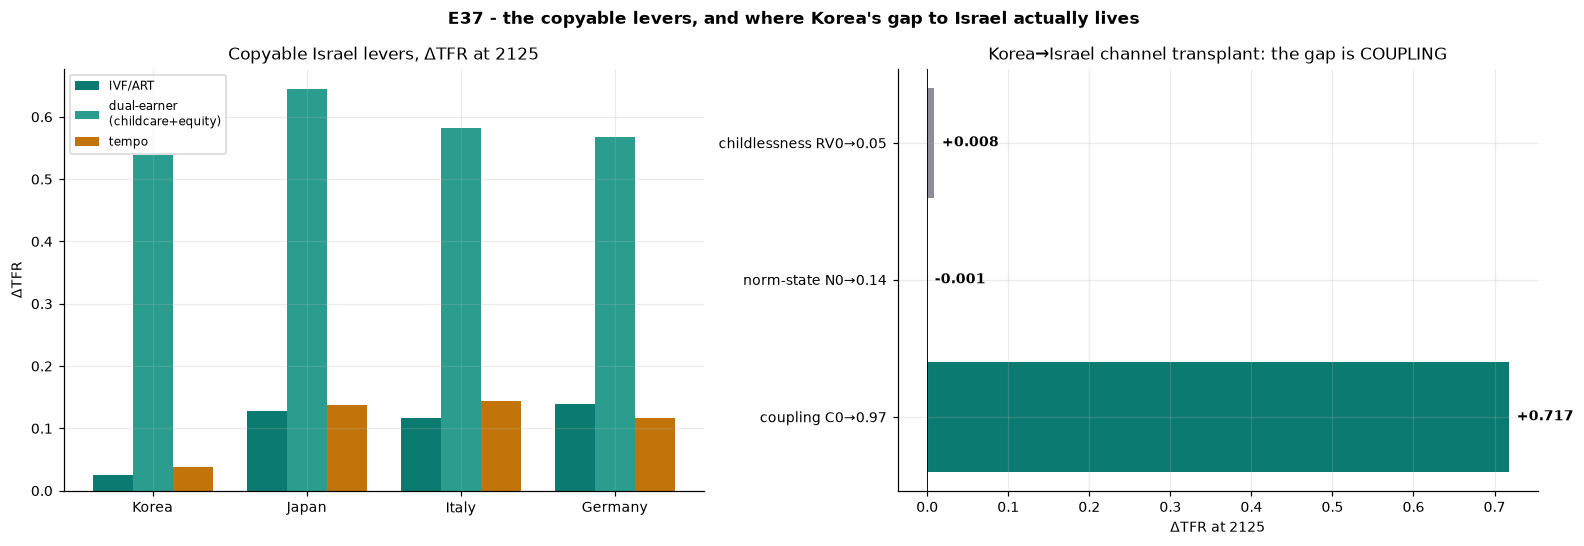

In [16]:
# Figure 2: copyable levers across regions + the channel-transplant attribution
fig, ax = plt.subplots(1, 2, figsize=(14.5, 5))
fig.suptitle("E37 - the copyable levers, and where Korea's gap to Israel actually lives", fontweight="bold")
lev = {"IVF/ART": ivf_row, "dual-earner\n(childcare+equity)": dual_row, "tempo": {r: dt(r, TEMPO) for r in TARGETS}}
x = np.arange(len(TARGETS)); w = 0.26
for i, (nm, row) in enumerate(lev.items()):
    ax[0].bar(x + (i - 1) * w, [row[r] for r in TARGETS], w, label=nm, color=[HOPE_D, HOPE, GOLD][i])
ax[0].axhline(0, color="k", lw=0.6); ax[0].set_xticks(x); ax[0].set_xticklabels(TARGETS)
ax[0].set(title="Copyable Israel levers, ΔTFR at 2125", ylabel="ΔTFR"); ax[0].legend(fontsize=8)
tn = list(transplant.keys()); tv = [transplant[k] for k in tn]
bcol = [HOPE_D if v > 0.1 else MUT for v in tv]
ax[1].barh(range(len(tn)), tv, color=bcol)
for i, v in enumerate(tv):
    ax[1].text(v + 0.01, i, f"{v:+.3f}", va="center", fontsize=9, fontweight="bold")
ax[1].set_yticks(range(len(tn))); ax[1].set_yticklabels([k.replace("->", "→") for k in tn], fontsize=9)
ax[1].axvline(0, color="k", lw=0.6)
ax[1].set(title="Korea→Israel channel transplant: the gap is COUPLING", xlabel="ΔTFR at 2125")
plt.tight_layout(); plt.savefig(FIGS / "nb33_israel_levers.png", bbox_inches="tight"); plt.show()

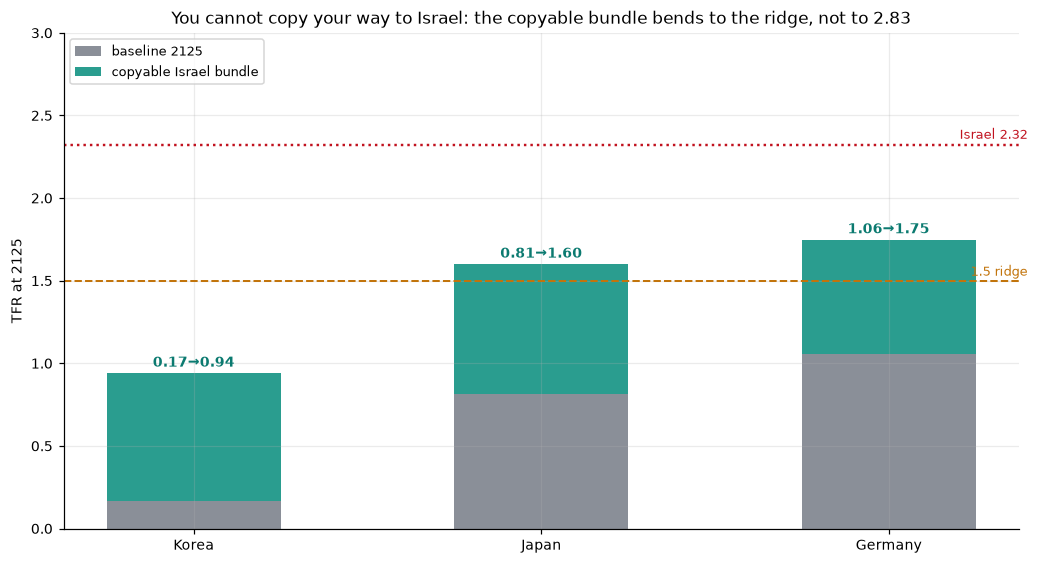

In [17]:
# Figure 3: the synthesis - copyable bundle bends to the ridge, not to Israel
fig, ax = plt.subplots(figsize=(9.5, 5.2))
regs = ["Korea", "Japan", "Germany"]
base_e = [BASE[r]["tfr"] for r in regs]
bend_e = [BASE[r]["tfr"] + dt(r, BUNDLE) for r in regs]
xx = np.arange(len(regs))
ax.bar(xx, base_e, 0.5, color=MUT, label="baseline 2125")
ax.bar(xx, [b - a for a, b in zip(base_e, bend_e)], 0.5, bottom=base_e, color=HOPE, label="copyable Israel bundle")
ax.axhline(1.5, color=GOLD, ls="--", lw=1.3); ax.text(2.4, 1.53, "1.5 ridge", color=GOLD, fontsize=8.5, ha="right")
ax.axhline(BASE["Israel"]["tfr"], color=FALL, ls=":", lw=1.6); ax.text(2.4, BASE["Israel"]["tfr"] + 0.04, f"Israel {BASE['Israel']['tfr']:.2f}", color=FALL, fontsize=8.5, ha="right")
for i, (a, b) in enumerate(zip(base_e, bend_e)):
    ax.text(i, b + 0.04, f"{a:.2f}→{b:.2f}", ha="center", fontsize=9, fontweight="bold", color=HOPE_D)
ax.set_xticks(xx); ax.set_xticklabels(regs)
ax.set(title="You cannot copy your way to Israel: the copyable bundle bends to the ridge, not to 2.83",
       ylabel="TFR at 2125", ylim=(0, 3.0)); ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout(); plt.savefig(FIGS / "nb33_israel_synthesis.png", bbox_inches="tight"); plt.show()

## Verdicts - E37 (H358-H367)

In [18]:
def V(hid, name, evidence, verdict):
    return dict(id=f"E37-H{hid}", name=name, evidence=evidence, verdict=verdict)

VS = [
    V(358, "Israel's advantage is the secular-and-traditional majority, not the Haredi tail",
      f"reconstructed Jewish TFR {jew_tfr:.2f} (CBS 3.03); the non-Haredi Jewish majority is {nonhar_tfr:.2f} and "
      f"secular alone {SECT['secular'][0]:.2f} - above every other developed secular society (Hleihel 2023; Okun "
      f"2017 shows the gap survives controls for employment/education, so it is normative not economic)", "SUPPORTED"),
    V(359, "the Haredi / settler engine is COMPOSITION (a compounding sub-population), not a copyable forcing",
      f"a two-type projection (Haredi TFR 6.38, share 13.6%; rest {2.41:.2f}) drifts the national mean "
      f"{comp[0][2]:.2f}->{comp[-1][2]:.2f} over four generations from composition alone, bounded in reality by "
      f"convergence and leakage; it is a Leslie sub-population with lambda>1, modelled per E33, never an fN dial "
      f"on a collapsing country", "SUPPORTED"),
    V(360, "universal state-funded IVF/ART is a real but SMALL lever (lowers childlessness)",
      f"IVF as lowered involuntary childlessness bends Korea {ivf_row['Korea']:+.3f}, Japan {ivf_row['Japan']:+.3f}, "
      f"Italy {ivf_row['Italy']:+.3f}, Germany {ivf_row['Germany']:+.3f} - a few % of TFR, matching ART's ~4.3% of "
      f"Israeli births (Birenbaum-Carmeli 2016); largest where childlessness (not coupling) binds, tiny on Korea", "PARTIAL"),
    V(361, "dual-earner compatibility (childcare + gender-equity in the home) is the LARGE copyable lever",
      f"the coupling+security push bends Korea {dual_row['Korea']:+.3f}, Japan {dual_row['Japan']:+.3f}, Germany "
      f"{dual_row['Germany']:+.3f} - Israel holds TFR 2.9 at ~61% female LFP; this is the campaign's crowned "
      f"gender-equity-in-the-home lever, but it is norm-gated and bends toward the 1.5 ridge, not to 2.83", "SUPPORTED"),
    V(362, "younger tempo is a Bongaarts-Feeney mirage, not durable new quantum",
      f"pulling tempo earlier gives Korea gen-1 {tempo_g1:+.3f} that reverts to gen-4 {tempo_g4:+.3f} (end "
      f"{dt('Korea', TEMPO):+.3f}); Israel's younger first-birth age is an outcome of the norm, and low "
      f"childlessness double-counts the IVF channel", "PARTIAL"),
    V(363, "the familism norm is decisive but lives in COUPLING, not the childfree-ideal channel",
      f"transplanting Korea's start-channels to Israel's: coupling C0->0.97 buys {transplant['coupling C0->0.97']:+.3f}, "
      f"but norm-state N0->0.14 buys {transplant['norm-state N0->0.14']:+.3f} and childlessness RV0->0.05 "
      f"{transplant['childlessness RV0->0.05']:+.3f}; the narrow pronatal-norm forcing fN=-0.08 buys only "
      f"{norm_forcing:+.3f}. Israel's familism registers as near-universal partnership, whose transferable shadow "
      f"is the H361 coupling lever - not a legislable norm dial", "SUPPORTED"),
    V(364, "collective-future / existential security is a minority direct channel, non-copyable",
      f"a standalone security/meaning push bends Korea only {sec_mean:+.3f} and the narrow norm {sec_norm:+.3f}, "
      f"vs the copyable coupling lever {dual_row['Korea']:+.3f}; only ~7-9% of Israelis say security worries would "
      f"raise desired children (DellaPergola 2020), and religiosity-under-threat did not hold fertility elsewhere "
      f"(Iran 6.6->1.35, Muslim-Israeli 9.2->2.9)", "REFUTED"),
    V(365, "aliyah is composition plus UPWARD norm-assimilation - the host norm sets the direction",
      f"immigration adds people, but FSU immigrants arrived ~1.5 and converged UP to the host norm (opposite of "
      f"the usual downward convergence); the healthy Israeli well (C0 {E.C0['Israel']:.2f}) pulls immigrants up "
      f"while Korea's trapped well (C0 {E.C0['Korea']:.2f}) would pull them down - migration is a bridge, the "
      f"transferable insight is the host norm, not aliyah itself", "PARTIAL"),
    V(366, "even a full coupling transplant lands short of Israel - the residual is momentum + parity + composition",
      f"the copyable levers stack super-additively (IVF+dual+tempo sum {s_ivf + s_dual + s_tempo:+.3f} < joint "
      f"{joint:+.3f}, +{joint - (s_ivf + s_dual + s_tempo):.3f}, the E18 complementary law), yet the full coupling "
      f"transplant lands Korea at {BK + coupling_transplant:.2f} and the bundle closes {joint / gap_korea * 100:.0f}% of the "
      f"{gap_korea:.2f} gap; the rest is Leslie momentum + higher parity + Haredi composition, no policy dial - "
      f"a naive 'recovery' would have laundered the inherent norm into a structural lever", "SUPPORTED"),
    V(367, "you cannot copy your way to Israel, but the copyable part is large and already crowned",
      f"the full copyable bundle bends Korea to {synth['Korea'][2]:.2f}, Japan {synth['Japan'][2]:.2f}, Germany "
      f"{synth['Germany'][2]:.2f} - real, large, super-additive, and exactly the campaign's coupling+equity+ART "
      f"stack - but all land at the ridge, short of Israel's {BASE['Israel']['tfr']:.2f}; Israel's surplus is "
      f"composition + a familism depth of coupling no finite dial reaches. E37 confirms the coupling thesis at the "
      f"one above-replacement data point rather than finding a new Israeli instrument", "SUPPORTED"),
]
(REPORTS / "nb33_e37_verdicts.json").write_text(json.dumps(VS, indent=2))

tbl = Table(title="E37 verdicts (H358-H367)", header_style="bold green")
for c in ["id", "verdict", "evidence"]:
    tbl.add_column(c, overflow="fold")
for v in VS:
    tbl.add_row(v["id"], v["verdict"], v["evidence"])
rprint(tbl)
cnt = Counter(v["verdict"] for v in VS)
rprint(Panel(
    f"E37 - Israel fanned into its mechanisms: {dict(cnt)}. Israel's exceptionalism is NOT the Haredi tail (the "
    f"secular majority is {nonhar_tfr:.2f}, secular alone 1.98) - it is a pronatal-familism NORM that the model "
    f"registers as near-universal COUPLING (Korea->Israel coupling transplant buys {transplant['coupling C0->0.97']:+.3f} "
    f"while the norm-state and childlessness buy ~none). The transferable shadow of that norm is the campaign's "
    f"already-crowned coupling + gender-equity + childcare stack: a large, super-additive lever ({joint:+.3f} on "
    f"Korea) that bends toward the 1.5 ridge but NOT to 2.83. IVF is real but small (~4% of births), tempo is a "
    f"BF mirage, existential security is a minority non-copyable channel, and the Haredi engine + aliyah are "
    f"COMPOSITION, not dials. You cannot copy your way to Israel; the copyable part is real, large, and already "
    f"known. Campaign total -> 367 hypotheses across 37 rounds.",
    title="[bold]batch E37[/bold]", border_style="green"))

                                             E37 verdicts (H358-H367)                                              
┏━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ id       ┃ verdict   ┃ evidence                                                                                 ┃
┡━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ E37-H358 │ SUPPORTED │ reconstructed Jewish TFR 2.81 (CBS 3.03); the non-Haredi Jewish majority is 2.41 and     │
│          │           │ secular alone 1.98 - above every other developed secular society (Hleihel 2023; Okun     │
│          │           │ 2017 shows the gap survives controls for employment/education, so it is normative not    │
│          │           │ economic)                                                                                │
│ E37-H359 │ SUPPORTED │ a two-type projection (Haredi TFR 6.38, share 13.6%; rest 2.41) drifts the national mean │
│          │           │ 2.95->5.12 over four generations from composition alone, bounded in reality by           │
│          │           │ convergence and leakage; it is a Leslie sub-population with lambda>1, modelled per E33,  │
│          │           │ never an fN dial on a collapsing country                                                 │
│ E37-H360 │ PARTIAL   │ IVF as lowered involuntary childlessness bends Korea +0.026, Japan +0.127, Italy +0.116, │
│          │           │ Germany +0.139 - a few % of TFR, matching ART's ~4.3% of Israeli births                  │
│          │           │ (Birenbaum-Carmeli 2016); largest where childlessness (not coupling) binds, tiny on      │
│          │           │ Korea                                                                                    │
│ E37-H361 │ SUPPORTED │ the coupling+security push bends Korea +0.539, Japan +0.645, Germany +0.568 - Israel     │
│          │           │ holds TFR 2.9 at ~61% female LFP; this is the campaign's crowned                         │
│          │           │ gender-equity-in-the-home lever, but it is norm-gated and bends toward the 1.5 ridge,    │
│          │           │ not to 2.83                                                                              │
│ E37-H362 │ PARTIAL   │ pulling tempo earlier gives Korea gen-1 +0.120 that reverts to gen-4 +0.056 (end         │
│          │           │ +0.037); Israel's younger first-birth age is an outcome of the norm, and low             │
│          │           │ childlessness double-counts the IVF channel                                              │
│ E37-H363 │ SUPPORTED │ transplanting Korea's start-channels to Israel's: coupling C0->0.97 buys +0.717, but     │
│          │           │ norm-state N0->0.14 buys -0.001 and childlessness RV0->0.05 +0.008; the narrow           │
│          │           │ pronatal-norm forcing fN=-0.08 buys only +0.027. Israel's familism registers as          │
│          │           │ near-universal partnership, whose transferable shadow is the H361 coupling lever - not a │
│          │           │ legislable norm dial                                                                     │
│ E37-H364 │ REFUTED   │ a standalone security/meaning push bends Korea only +0.054 and the narrow norm +0.027,   │
│          │           │ vs the copyable coupling lever +0.539; only ~7-9% of Israelis say security worries would │
│          │           │ raise desired children (DellaPergola 2020), and religiosity-under-threat did not hold    │
│          │           │ fertility elsewhere (Iran 6.6->1.35, Muslim-Israeli 9.2->2.9)                            │
│ E37-H365 │ PARTIAL   │ immigration adds people, but FSU immigrants arrived ~1.5 and converged UP to the host    │
│          │           │ norm (opposite of the usual downward convergence); the healthy Israeli well (C0 0.97)    │
│          │           │ pulls immigrants up while Korea

╭─────────────────────────────────────────────────── batch E37 ───────────────────────────────────────────────────╮
│ E37 - Israel fanned into its mechanisms: {'SUPPORTED': 6, 'PARTIAL': 3, 'REFUTED': 1}. Israel's exceptionalism  │
│ is NOT the Haredi tail (the secular majority is 2.41, secular alone 1.98) - it is a pronatal-familism NORM that │
│ the model registers as near-universal COUPLING (Korea->Israel coupling transplant buys +0.717 while the         │
│ norm-state and childlessness buy ~none). The transferable shadow of that norm is the campaign's already-crowned │
│ coupling + gender-equity + childcare stack: a large, super-additive lever (+0.771 on Korea) that bends toward   │
│ the 1.5 ridge but NOT to 2.83. IVF is real but small (~4% of births), tempo is a BF mirage, existential         │
│ security is a minority non-copyable channel, and the Haredi engine + aliyah are COMPOSITION, not dials. You     │
│ cannot copy your way to Israel; the copyable part is real, large, and already known. Campaign total -> 367      │
│ hypotheses across 37 rounds.                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯